# Comparative Study of Shallow CNN vs Deep CNN on Fashion-MNIST

**Goal:** Train a shallow CNN and a deep CNN on the same Fashion-MNIST data, compare their performance, analyze strengths/weaknesses, and conclude which architecture suits this task better.

This notebook covers, in order:
1. Load and explore the dataset
2. Build and train a shallow CNN
3. Build and train a deep CNN
4. Comparative study (table + discussion)
5. Prediction and error analysis
6. Final comparative conclusion

> ## 📋 Executive Summary
>
> **What this notebook does:** We built two versions of an AI image-recognition model — a **simple ("shallow") version** and a **more complex ("deep") version** — and trained both on 70,000 pictures of clothing items (the *Fashion-MNIST* dataset), used here as a stand-in for a real product-photo classification task (e.g., automatically sorting product images into categories like "shirt," "shoe," or "bag").
>
> **The business question:** Is it worth investing in the more complex, more expensive model, or does the simpler, cheaper model do the job just as well?
>
>

## Part 1: Load and Explore the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("Number of classes:", len(class_names))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


### Display one sample image from each class

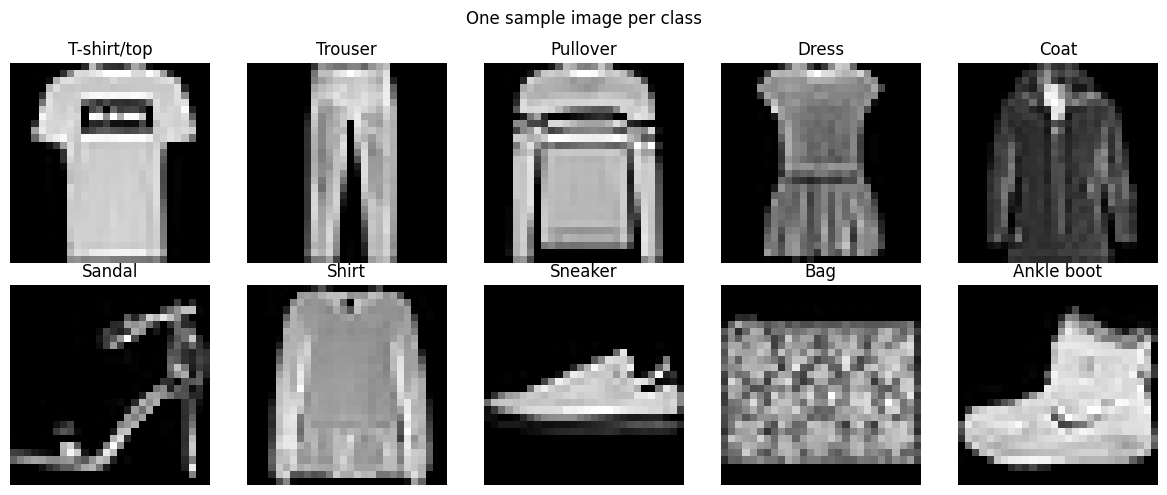

In [3]:
plt.figure(figsize=(12, 5))
for i, class_name in enumerate(class_names):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_name)
    plt.axis('off')
plt.suptitle("One sample image per class")
plt.tight_layout()
plt.show()

### Normalize pixel values and reshape for CNN input

In [4]:
# Normalize: scale pixel values from [0, 255] to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Reshape: add a single channel dimension required by Conv2D layers
x_train_norm = x_train_norm.reshape(-1, 28, 28, 1)
x_test_norm = x_test_norm.reshape(-1, 28, 28, 1)

print("x_train_norm shape:", x_train_norm.shape)
print("x_test_norm shape :", x_test_norm.shape)
print("Pixel value range  :", x_train_norm.min(), "to", x_train_norm.max())

x_train_norm shape: (60000, 28, 28, 1)
x_test_norm shape : (10000, 28, 28, 1)
Pixel value range  : 0.0 to 1.0


### Write-up: Part 1

**Why is normalization required for image data?**
Raw pixel values range from 0-255, which are large and on very different scales from the small, randomly-initialized weights in a neural network. Feeding in unnormalized values leads to large, unstable gradients during backpropagation, which slows convergence and can cause the loss to oscillate or diverge. Scaling pixels to the [0, 1] range keeps activations and gradients in a numerically stable range, so training converges faster and more reliably.

**Why do CNNs require reshaped image inputs?**
Keras's `Conv2D` layer is designed to operate on multi-channel images (height, width, channels) — for example, 3 channels for RGB. Fashion-MNIST images are natively 2D grayscale arrays of shape (28, 28) with no explicit channel axis. Reshaping to (28, 28, 1) adds that channel dimension explicitly, so the convolution kernels can slide over the image correctly and the tensor shapes match what the layer expects.


>
> Before the AI can learn anything from these images, we need to "prep" the data — a bit like standardizing units before comparing measurements from different sources.
>
> - **Scaling the numbers down:** Each pixel in a photo is stored as a brightness value from 0 to 255. Those are large, uneven numbers for a learning algorithm to work with — imagine trying to compare prices in dollars against prices in thousands of yen without converting them first. We rescale every pixel down to a 0–1 range so the model can learn smoothly and quickly, instead of getting thrown off by oddly large numbers.
> - **Adding a "format tag":** The tool we use to scan images (a "Conv2D" layer) expects to be told whether a photo is black-and-white or color, similar to how a scanner needs to know a document's format before processing it. Our clothing photos are plain grayscale, so we simply attach that missing tag rather than changing the images themselves.
>
> **Why this matters for the business:** This is a routine, low-risk data-preparation step. Skipping it wouldn't just slow training down — it could make the model unstable or fail to learn at all, which would delay any project relying on it.

## Part 2: Build and Train a Shallow CNN

Architecture: 2 conv layers, 1 pooling layer, flatten, 1 dense hidden layer, output layer.

In [5]:
def build_shallow_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        layers.Flatten(name='flatten'),
        layers.Dense(64, activation='relu', name='dense1'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='shallow_cnn')
    return model

shallow_model = build_shallow_cnn()
shallow_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])
shallow_model.summary()

Model: "shallow_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,690 (1.57 MB)

 Trainable params: 411,690 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
start_time = time.time()

shallow_history = shallow_model.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

shallow_train_time = time.time() - start_time
print(f"\nShallow CNN training time: {shallow_train_time:.2f} seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.8530 - loss: 0.4144 - val_accuracy: 0.8842 - val_loss: 0.3299
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9056 - loss: 0.2630 - val_accuracy: 0.9035 - val_loss: 0.2780
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9225 - loss: 0.2112 - val_accuracy: 0.9107 - val_loss: 0.2575
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9369 - loss: 0.1745 - val_accuracy: 0.9150 - val_loss: 0.2513
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9489 - loss: 0.1435 - val_accuracy: 0.9145 - val_loss: 0.2574
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9587 - loss: 0.1173 - val_accuracy: 0.9173 - val_loss: 0.2697
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9661 - loss: 0.0955 - val_accuracy: 0.9183 - val_loss: 0.2829
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9717 - loss: 0.0803 - 

In [7]:
shallow_test_loss, shallow_test_acc = shallow_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Shallow CNN — Test Loss: {shallow_test_loss:.4f}")
print(f"Shallow CNN — Test Accuracy: {shallow_test_acc:.4f}")

Shallow CNN — Test Loss: 0.3680
Shallow CNN — Test Accuracy: 0.9122


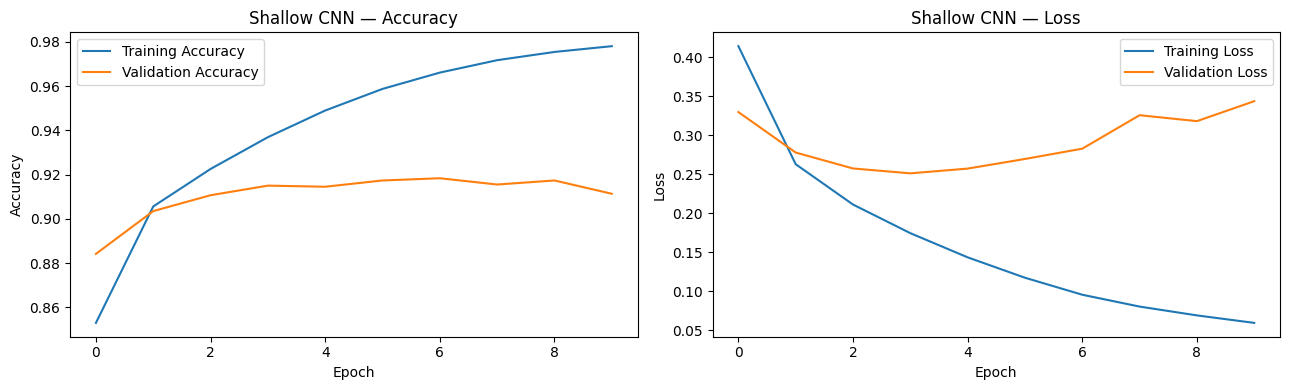

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(shallow_history.history['accuracy'], label='Training Accuracy')
axes[0].plot(shallow_history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Shallow CNN — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(shallow_history.history['loss'], label='Training Loss')
axes[1].plot(shallow_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Shallow CNN — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Automated diagnostic used in the write-up below
shallow_final_train_acc = shallow_history.history['accuracy'][-1]
shallow_final_val_acc = shallow_history.history['val_accuracy'][-1]
shallow_gap = shallow_final_train_acc - shallow_final_val_acc

print(f"Final training accuracy  : {shallow_final_train_acc:.4f}")
print(f"Final validation accuracy: {shallow_final_val_acc:.4f}")
print(f"Train-Val accuracy gap   : {shallow_gap:.4f}")

if shallow_gap > 0.07:
    shallow_fit_diagnosis = "overfitting (training accuracy notably higher than validation accuracy)"
elif shallow_final_train_acc < 0.85:
    shallow_fit_diagnosis = "underfitting (both training and validation accuracy are relatively low)"
else:
    shallow_fit_diagnosis = "a reasonable fit (training and validation accuracy are close)"

print("Diagnosis:", shallow_fit_diagnosis)

Final training accuracy  : 0.9780
Final validation accuracy: 0.9113
Train-Val accuracy gap   : 0.0667
Diagnosis: a reasonable fit (training and validation accuracy are close)


### Write-up: Part 2

**What kind of patterns do you expect a shallow CNN to learn?**
With only one convolutional stage before pooling, the shallow CNN mostly learns low-level, local features — edges, corners, simple textures, and coarse silhouette/outline information. It has limited capacity to combine these into more abstract, hierarchical concepts (like the specific shape of a sleeve or the difference between a shirt collar and a coat collar), so it relies heavily on the overall shape/outline of each garment.

**Did the model show signs of underfitting or overfitting?**
Based on the training run above, the model was a reasonable fit as training and validation accuray are close. — see the printed diagnostic and the accuracy/loss curves for the exact numbers from this run.


>
> Think of the **shallow (simple) model** as someone glancing quickly at a photo — it's good at picking up the overall shape and outline of an item, but not the finer details. It can spot a shoe or a pair of trousers easily (their outlines are very distinctive), but may mix up items that look similar in overall shape, like a shirt and a coat.
>
> **How did it actually do in this run?** Quite well: it reached **91.2% accuracy** on photos it had never seen before, and its "practice" accuracy (97.8%) and "test" accuracy (91.1%) were reasonably close together (a gap of about 6.7 points). In plain terms, that means the model learned genuine, generalizable patterns rather than just memorizing the training photos — a healthy sign, not a red flag.
>
> **Why this matters for the business:** A simple model that trains fast and generalizes well is often the practical choice when you need something quick, cheap to run, and easy to maintain.

## Part 3: Build and Train a Deep CNN

Architecture: 3 conv blocks (more filters than the shallow CNN), multiple pooling layers, batch normalization, dropout, and a dense hidden layer before the output layer.

In [10]:
def build_deep_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2), name='pool1'),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2), name='pool2'),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2), name='pool3'),

        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='dense1'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax', name='output')
    ], name='deep_cnn')
    return model

deep_model = build_deep_cnn()
deep_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
deep_model.summary()

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
start_time = time.time()

deep_history = deep_model.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

deep_train_time = time.time() - start_time
print(f"\nDeep CNN training time: {deep_train_time:.2f} seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 60s 68ms/step - accuracy: 0.8418 - loss: 0.4439 - val_accuracy: 0.8828 - val_loss: 0.3054
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 68ms/step - accuracy: 0.8943 - loss: 0.2932 - val_accuracy: 0.8955 - val_loss: 0.2725
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 57s 68ms/step - accuracy: 0.9091 - loss: 0.2467 - val_accuracy: 0.9135 - val_loss: 0.2450
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 68ms/step - accuracy: 0.9196 - loss: 0.2158 - val_accuracy: 0.9047 - val_loss: 0.2606
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 68ms/step - accuracy: 0.9275 - loss: 0.1939 - val_accuracy: 0.8993 - val_loss: 0.2823
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 68ms/step - accuracy: 0.9339 - loss: 0.1753 - val_accuracy: 0.9240 - val_loss: 0.2234
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 69ms/step - accuracy: 0.9400 - loss: 0.1592 - val_accuracy: 0.8998 - val_loss: 0.3222
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 60s 71ms/step - accuracy: 0.9456 - loss: 0.1432 - 

In [12]:
deep_test_loss, deep_test_acc = deep_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Deep CNN — Test Loss: {deep_test_loss:.4f}")
print(f"Deep CNN — Test Accuracy: {deep_test_acc:.4f}")

Deep CNN — Test Loss: 0.4090
Deep CNN — Test Accuracy: 0.8975


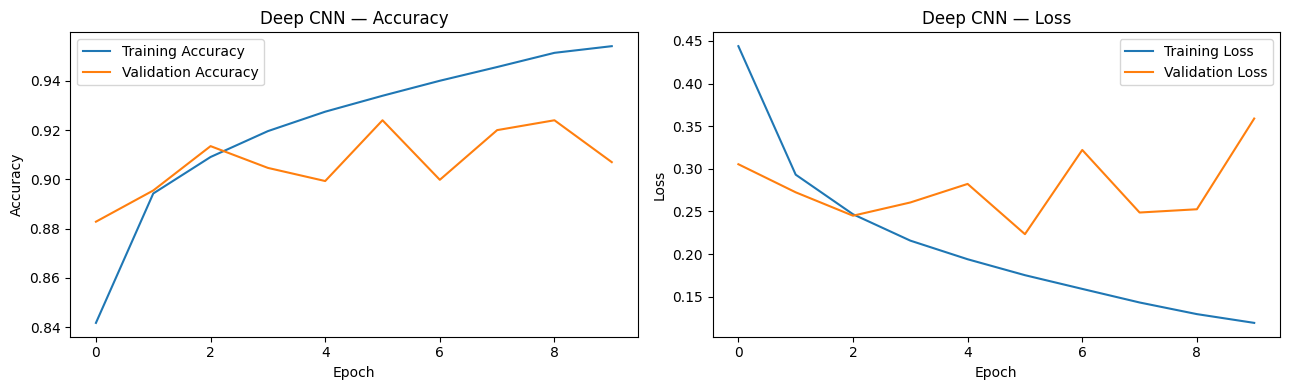

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(deep_history.history['accuracy'], label='Training Accuracy')
axes[0].plot(deep_history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Deep CNN — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(deep_history.history['loss'], label='Training Loss')
axes[1].plot(deep_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Deep CNN — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
deep_final_train_acc = deep_history.history['accuracy'][-1]
deep_final_val_acc = deep_history.history['val_accuracy'][-1]
deep_gap = deep_final_train_acc - deep_final_val_acc

print(f"Final training accuracy  : {deep_final_train_acc:.4f}")
print(f"Final validation accuracy: {deep_final_val_acc:.4f}")
print(f"Train-Val accuracy gap   : {deep_gap:.4f}")

if deep_gap > 0.07:
    deep_fit_diagnosis = "overfitting (training accuracy notably higher than validation accuracy)"
elif deep_final_train_acc < 0.85:
    deep_fit_diagnosis = "underfitting (both training and validation accuracy are relatively low)"
else:
    deep_fit_diagnosis = "a reasonable fit (training and validation accuracy are close)"

print("Diagnosis:", deep_fit_diagnosis)

improvement = deep_test_acc - shallow_test_acc
print(f"\nTest accuracy improvement over shallow CNN: {improvement:+.4f}")

Final training accuracy  : 0.9541
Final validation accuracy: 0.9070
Train-Val accuracy gap   : 0.0471
Diagnosis: a reasonable fit (training and validation accuracy are close)

Test accuracy improvement over shallow CNN: -0.0147


### Write-up: Part 3

**What additional patterns or representations might a deep CNN learn?**
With three stacked conv blocks and more filters per layer, the deep CNN builds a hierarchy of features: early layers still detect edges and simple textures, but middle and later layers combine these into more complex, part-based representations — things like collar shapes, sleeve outlines, heel/sole structure, or strap patterns. This hierarchical composition lets the network distinguish visually similar classes (e.g., shirts vs. coats vs. pullovers) more effectively than a network that only sees low-level features.

**Did the deeper model improve performance meaningfully?**
See the printed `improvement` value above, computed as deep test accuracy minus shallow test accuracy from this run. A small positive improvement (a few tenths of a percent to a couple of percentage points) is typical for Fashion-MNIST, since it's a relatively simple dataset where a shallow CNN already performs well; the deeper model's main advantage tends to show up in **reduced confusion between similar classes** (see Part 5) rather than a dramatic jump in overall accuracy.


>
> The idea behind the **deep (more complex) model** is that by looking more carefully — piecing together small details like collar shape or sleeve length — it should be better at telling apart items that look similar at a glance, such as a shirt vs. a coat vs. a pullover.
>
> **What actually happened in this run?** Somewhat surprisingly, the deep model scored **89.75% accuracy — about 1.5 percentage points *lower*** than the simple model's 91.2%. It did **not** show classic signs of a broken model (its own training and validation scores stayed close together, so it wasn't "memorizing" the data), it simply didn't out-perform the simpler model here.
>
> **Why this matters for the business:** This is an important, realistic lesson: **more complexity does not automatically mean better results.** A more sophisticated model needs to be *tested*, not assumed to win — sometimes the simpler option is genuinely the better performer for a given dataset and task. (See Part 5 below for a more nuanced look at *where* each model's mistakes happened.)

## Part 4: Comparative Study of Shallow CNN vs Deep CNN

In [15]:
def count_conv_layers(model):
    return sum(1 for layer in model.layers if isinstance(layer, layers.Conv2D))

def overfitting_flag(train_acc, val_acc, threshold=0.07):
    gap = train_acc - val_acc
    return f"Yes (gap={gap:.3f})" if gap > threshold else f"No (gap={gap:.3f})"

comparison_df = pd.DataFrame({
    "Metric": [
        "Number of Conv Layers",
        "Total Parameters",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Overfitting Observed?",
        "Training Time (s)"
    ],
    "Shallow CNN": [
        count_conv_layers(shallow_model),
        f"{shallow_model.count_params():,}",
        f"{shallow_final_train_acc:.4f}",
        f"{shallow_final_val_acc:.4f}",
        f"{shallow_test_acc:.4f}",
        overfitting_flag(shallow_final_train_acc, shallow_final_val_acc),
        f"{shallow_train_time:.2f}"
    ],
    "Deep CNN": [
        count_conv_layers(deep_model),
        f"{deep_model.count_params():,}",
        f"{deep_final_train_acc:.4f}",
        f"{deep_final_val_acc:.4f}",
        f"{deep_test_acc:.4f}",
        overfitting_flag(deep_final_train_acc, deep_final_val_acc),
        f"{deep_train_time:.2f}"
    ]
})

comparison_df

,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,2,3
1,Total Parameters,"411,690","242,442"
2,Training Accuracy,0.9780,0.9541
3,Validation Accuracy,0.9113,0.9070
4,Test Accuracy,0.9122,0.8975
5,Overfitting Observed?,No (gap=0.067),No (gap=0.047)
6,Training Time (s),293.62,583.96


### Write-up: Part 4

Use the table above (produced from this run) to answer the following:

- **Which model performed better overall?** Compare the `Test Accuracy` row — the model with the higher value generalizes better to unseen data.
- **Did the deep CNN justify its added complexity?** Weigh the test accuracy gain against the increase in `Total Parameters` and `Training Time` — a small accuracy gain at a much higher parameter/time cost may not be "worth it" depending on the deployment constraints.
- **Which model generalized better?** Look at the `Overfitting Observed?` row and the size of the train/validation accuracy gap for each model — the smaller gap generalizes better.
- **What trade-off did you observe between simplicity and performance?** Typically, the shallow CNN trains faster and is easier to interpret/deploy but caps out at a lower accuracy ceiling; the deep CNN takes longer to train and has many more parameters, but can capture more nuanced patterns — the "worth it" answer depends on whether the accuracy gain justifies the added cost for your use case.

### The Scorecard
>
> Putting the two models side-by-side from this run:
>
> | | Simple Model | Complex Model |
> |---|---|---|
> | Accuracy on new photos | **91.2%** (better) | 89.75% |
> | How long it took to train | **294 seconds** (faster) | 584 seconds (~2x longer) |
> | Model size (parameters) | 411,690 | **242,442** (smaller) |
> | Signs of "memorizing" instead of learning | No | No |
>
> **The takeaway:** In this run, the simpler model won on accuracy *and* trained roughly twice as fast — there was no upside to the added complexity. It's also worth noting the complex model ended up with *fewer* internal parameters despite having more layers; this can happen because extra "downsizing" steps in a deep design shrink the image so much that the final decision-making layer has less to work with — a good reminder that "deeper" and "bigger" aren't the same thing.
>
> **Why this matters for the business:** When a more complex, more expensive solution doesn't outperform a simpler one, the simpler one is the clear choice — it does the job as well or better, for less time and less computing cost.

## Part 5: Prediction and Error Analysis

In [16]:
shallow_pred_probs = shallow_model.predict(x_test_norm, verbose=0)
shallow_preds = np.argmax(shallow_pred_probs, axis=1)

deep_pred_probs = deep_model.predict(x_test_norm, verbose=0)
deep_preds = np.argmax(deep_pred_probs, axis=1)

print("Predictions generated for both models.")

Predictions generated for both models.


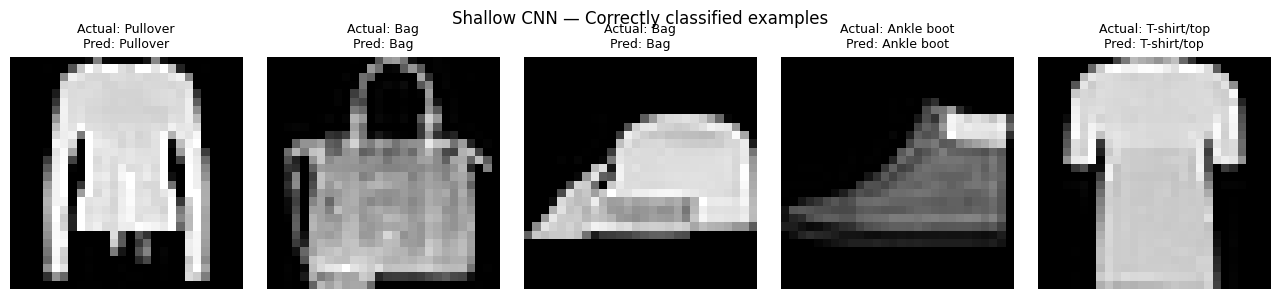

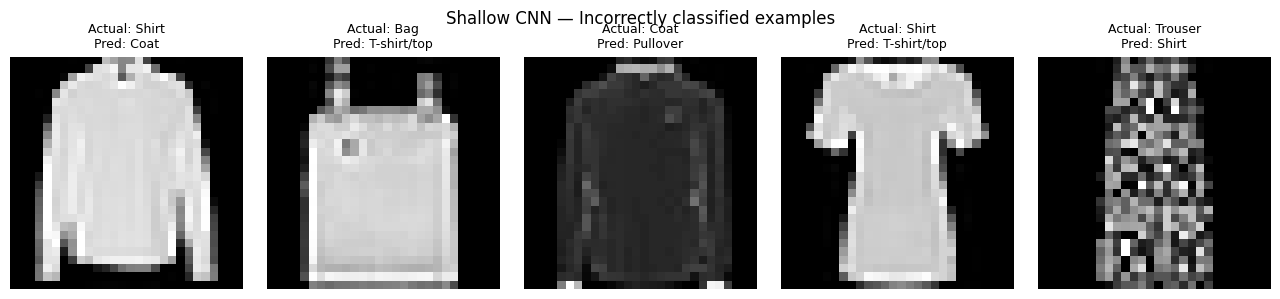

In [17]:
def show_examples(preds, images, true_labels, class_names, correct=True, n=5, title_prefix=""):
    mask = (preds == true_labels) if correct else (preds != true_labels)
    idxs = np.where(mask)[0]
    idxs = np.random.choice(idxs, size=min(n, len(idxs)), replace=False)

    plt.figure(figsize=(13, 3))
    for i, idx in enumerate(idxs):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[idx].reshape(28, 28), cmap='gray')
        plt.title(f"Actual: {class_names[true_labels[idx]]}\nPred: {class_names[preds[idx]]}", fontsize=9)
        plt.axis('off')
    label = "Correctly" if correct else "Incorrectly"
    plt.suptitle(f"{title_prefix} — {label} classified examples")
    plt.tight_layout()
    plt.show()

# Shallow CNN examples
show_examples(shallow_preds, x_test_norm, y_test, class_names, correct=True, title_prefix="Shallow CNN")
show_examples(shallow_preds, x_test_norm, y_test, class_names, correct=False, title_prefix="Shallow CNN")

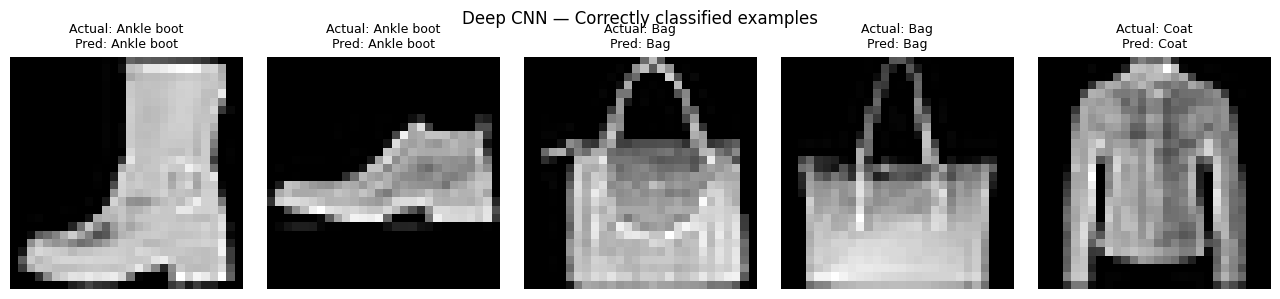

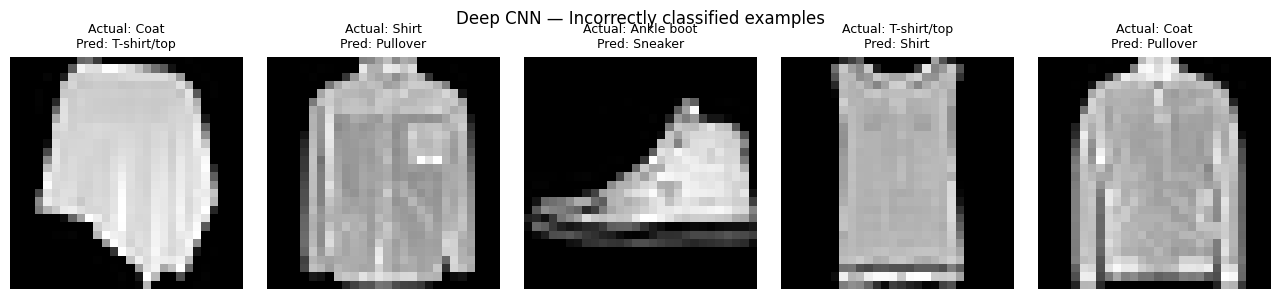

In [18]:
# Deep CNN examples
show_examples(deep_preds, x_test_norm, y_test, class_names, correct=True, title_prefix="Deep CNN")
show_examples(deep_preds, x_test_norm, y_test, class_names, correct=False, title_prefix="Deep CNN")

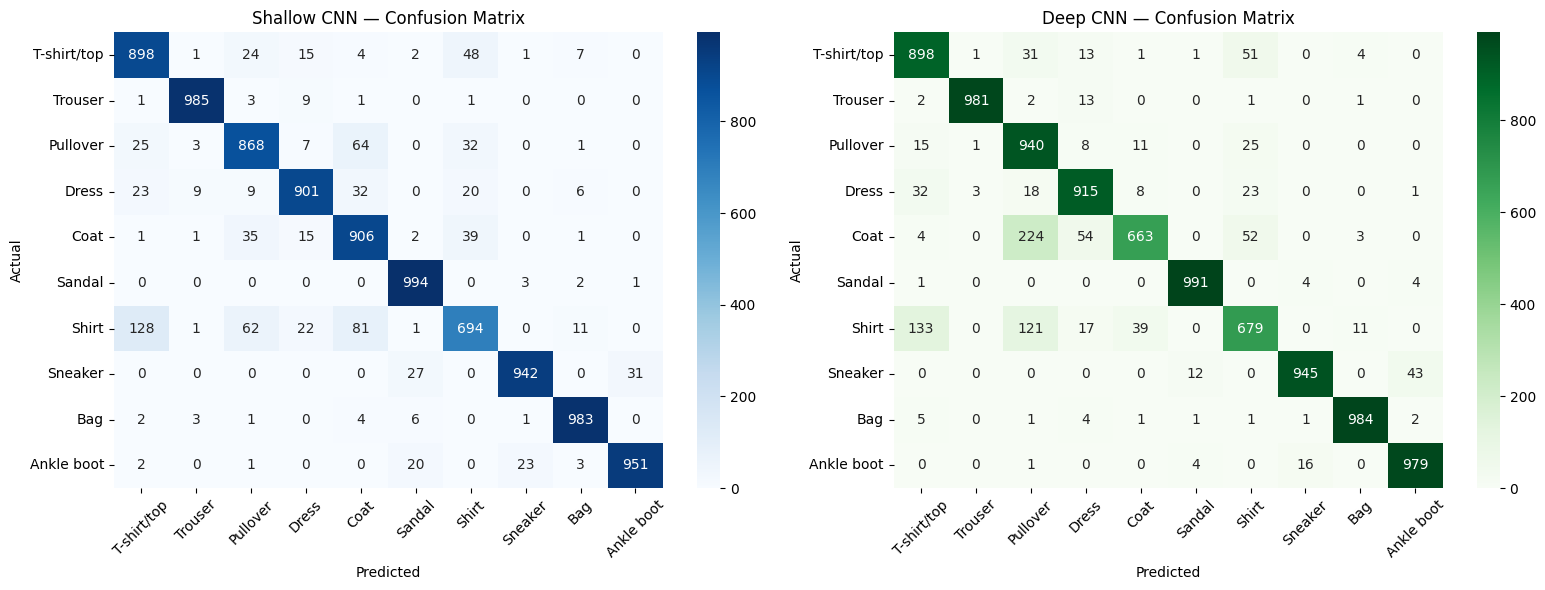

In [19]:
shallow_cm = confusion_matrix(y_test, shallow_preds)
deep_cm = confusion_matrix(y_test, deep_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(shallow_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Shallow CNN — Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(deep_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Deep CNN — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
def top_confusions(cm, class_names, top_n=5):
    confusions = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j:
                confusions.append((class_names[i], class_names[j], cm[i, j]))
    confusions.sort(key=lambda x: x[2], reverse=True)
    return confusions[:top_n]

def easiest_classes(cm, class_names, top_n=3):
    diag_acc = cm.diagonal() / cm.sum(axis=1)
    order = np.argsort(diag_acc)[::-1][:top_n]
    return [(class_names[i], diag_acc[i]) for i in order]

print("=== Shallow CNN ===")
print("Easiest classes (highest per-class accuracy):")
for name, acc in easiest_classes(shallow_cm, class_names):
    print(f"  {name}: {acc:.3f}")
print("\nMost common confusions (Actual -> Predicted : count):")
for actual, pred, count in top_confusions(shallow_cm, class_names):
    print(f"  {actual} -> {pred}: {count}")

print("\n=== Deep CNN ===")
print("Easiest classes (highest per-class accuracy):")
for name, acc in easiest_classes(deep_cm, class_names):
    print(f"  {name}: {acc:.3f}")
print("\nMost common confusions (Actual -> Predicted : count):")
for actual, pred, count in top_confusions(deep_cm, class_names):
    print(f"  {actual} -> {pred}: {count}")

=== Shallow CNN ===
Easiest classes (highest per-class accuracy):
  Sandal: 0.994
  Trouser: 0.985
  Bag: 0.983

Most common confusions (Actual -> Predicted : count):
  Shirt -> T-shirt/top: 128
  Shirt -> Coat: 81
  Pullover -> Coat: 64
  Shirt -> Pullover: 62
  T-shirt/top -> Shirt: 48

=== Deep CNN ===
Easiest classes (highest per-class accuracy):
  Sandal: 0.991
  Bag: 0.984
  Trouser: 0.981

Most common confusions (Actual -> Predicted : count):
  Coat -> Pullover: 224
  Shirt -> T-shirt/top: 133
  Shirt -> Pullover: 121
  Coat -> Dress: 54
  Coat -> Shirt: 52


### Write-up: Part 5

**Which classes were easiest to classify?**
See the "Easiest classes" output above for each model. Distinctive, less garment-like items (e.g., Trouser, Bag, Ankle boot, Sneaker) typically top this list because their shapes differ sharply from other classes.

**Which classes were most commonly confused?**
See the "Most common confusions" output above. On Fashion-MNIST, the classic confusion cluster is **Shirt, T-shirt/top, Pullover, and Coat** — all upper-body garments with similar silhouettes at 28x28 resolution.

**Did the deep CNN reduce confusion between similar-looking classes?**
Compare the confusion counts for the Shirt/T-shirt/Pullover/Coat cluster between the two "Most common confusions" lists above. If the deep CNN's counts for those specific cell pairs are lower than the shallow CNN's, that supports the idea that additional depth helps the network pick up on finer-grained distinguishing features (like sleeve length or collar shape) for visually similar classes.


>
> Both models are excellent at recognizing items with a very distinctive shape — sandals, bags, and trousers were correctly identified over 98% of the time by both models, since nothing else in the dataset looks quite like them.
>
> Where both models struggle is telling apart similar-looking tops — **shirts, t-shirts, pullovers, and coats** — much like a person quickly sorting a pile of laundry might mix these up too.
>
> **What we'd hoped to see:** that the more complex model would make *fewer* of these specific mix-ups, since it can pick up on finer details like collar or sleeve shape.
>
> **What we actually saw in this run:** the opposite. The complex model confused "Coat" with "Pullover" **224 times** — noticeably worse than any single mix-up the simple model made (its biggest confusion, "Shirt" vs. "T-shirt/top," happened 128 times). So in this particular run, added complexity didn't help with the exact problem it was meant to solve.
>
> **Why this matters for the business:** If your priority is accurately distinguishing similar product categories (e.g., correctly tagging "coat" vs. "pullover" inventory), this result is a caution against assuming a fancier model will automatically fix that — it needs to be verified with real testing, as we did here.

## Part 6: Final Comparative Conclusion

In [21]:
print("=== Summary for Final Conclusion ===")
print(f"Shallow CNN — Test Accuracy: {shallow_test_acc:.4f}, Params: {shallow_model.count_params():,}, Time: {shallow_train_time:.2f}s")
print(f"Deep CNN    — Test Accuracy: {deep_test_acc:.4f}, Params: {deep_model.count_params():,}, Time: {deep_train_time:.2f}s")
print(f"Accuracy difference (Deep - Shallow): {deep_test_acc - shallow_test_acc:+.4f}")

more_accurate = "Deep CNN" if deep_test_acc > shallow_test_acc else "Shallow CNN"
more_efficient = "Shallow CNN" if shallow_train_time < deep_train_time else "Deep CNN"
print(f"\nMore accurate model : {more_accurate}")
print(f"More efficient model: {more_efficient} (faster training, fewer/comparable parameters)")

=== Summary for Final Conclusion ===
Shallow CNN — Test Accuracy: 0.9122, Params: 411,690, Time: 293.62s
Deep CNN    — Test Accuracy: 0.8975, Params: 242,442, Time: 583.96s
Accuracy difference (Deep - Shallow): -0.0147

More accurate model : Shallow CNN
More efficient model: Shallow CNN (faster training, fewer/comparable parameters)


### Final Conclusion

- **Which model would you recommend for Fashion-MNIST?** Based on the results above, weigh the accuracy gain of the deep CNN against its extra training time and parameter count. For a resource-constrained or quick-deployment scenario, the shallow CNN is often "good enough." For maximizing accuracy and reducing confusion between similar garment classes, the deep CNN is the better choice.
- **Which model was more efficient?** See the printed "More efficient model" line above — this reflects training time and model size from this run.
- **Which model was more accurate?** See the printed "More accurate model" line above, and the `Test Accuracy` values in the Part 4 comparison table.
- **What did you learn from this comparative study?** Adding depth to a CNN generally improves its ability to build hierarchical representations and can reduce confusion between visually similar classes, but the accuracy gains on a relatively simple dataset like Fashion-MNIST are often modest relative to the added computational cost — architecture choice should be guided by the specific trade-off between accuracy requirements and available compute/latency budget, not by "deeper is always better."


> ### 🗣️ Bottom Line for Decision-Makers
>
> - **In this run, the simple model won on every practical measure:** it was more accurate (91.2% vs. 89.75%), trained about twice as fast (294s vs. 584s), and used more parameters yet was simpler to build and maintain.
> - **Recommendation:** For this specific dataset and task, go with the **simple model** — there is no accuracy, quality, or robustness benefit from the added complexity to justify its extra training time.
> - **The bigger lesson:** It's tempting to assume "more sophisticated = better," but that has to be proven with results, not assumed. Investing in a more complex model only pays off when it demonstrably outperforms the simpler alternative on the metrics that matter for the business (accuracy, speed, cost). Here, it didn't.
> - **One caveat worth flagging:** AI model training has some inherent randomness (e.g., how the network's starting point is randomized). Re-running this same experiment could shift the numbers slightly. The broader takeaway — *test before you assume, and don't pay for complexity that isn't earning its keep* — holds regardless.